# Benchmark de EDs para Escalonamento e Priorização de Pacotes em Redes Restritas

## Table of contents

- Introdução
- Dados de teste
- EDs (Binary Heaps, Fibonacci Heaps, Pairing Heaps)
- Testes

## Introdução


In [30]:
%pip install pandas numpy gdown matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 1.4 MB/s eta 0:00:00a 0:00:01
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 2.4 MB/s eta 0:00:00a 0:00:01
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 16.2 MB/s eta 0:00:0000:010:01
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 16.5 MB/s eta 0:00:0000:0100:01
Using cached kiwisolver-1.5.0-cp312-cp31

In [1]:
#@title Imports
import pandas as pd
import numpy as np
import gdown
import math
from time import time
from time import sleep
import matplotlib.pyplot as plt
from functools import total_ordering

## Dados de teste

A primeira célula pega os arquivos direto da fonte original e trata do zero, a segunda célula pega os arquivos já tratados prontos para usar

No banco de dados MIMIC-III, a coluna **warning** na tabela chartevents atua como um sinalizador binário (0 ou 1) que indica se um alerta clínico ou uma observação manual foi documentado pelo profissional de saúde. [[1]](https://github.com/MIT-LCP/mimic-code/issues/472)

In [ ]:
#@title Obtendo dados de teste e salvando no drive

# Dados reais
# !wget -O chartevents.csv https://physionet.org/files/mimiciii-demo/1.4/CHARTEVENTS.csv?download
# chartevents = pd.read_csv("chartevents.csv")
# warning_stream = chartevents[["charttime", "warning"]].sort_values(by="charttime")
# warning_stream.to_csv("real_warning_stream.csv", index=False)

# Dados sintéticos
# def sintetic_data(prob=0.20,n_linhas=100_000,data_inicio='2026-01-01',data_fim='2026-12-31'):
#   datas = pd.date_range(start=data_inicio, end=data_fim, freq='s')
#   datas_registro = np.random.choice(datas, size=n_linhas, replace=True)
#   datas_registro.sort()

#   valores = np.random.choice([0, 1], size=n_linhas, p=[1-prob, prob])

#   df_sintetico = pd.DataFrame({
#       'charttime': datas_registro,
#       'warning': valores
#   })
#   df_sintetico.to_csv(f'sintetic_prob_{int(prob*100)}.csv', index=False)
#   return df_sintetico

# sintetic_02 = sintetic_data(prob=0.02, n_linhas=100_000)
# sintetic_20 = sintetic_data(n_linhas=100_000)
# sintetic_50 = sintetic_data(prob=0.5, n_linhas=100_000)
# sintetic_70 = sintetic_data(prob=0.7, n_linhas=100_000)

# real_warning_stream = pd.read_csv('real_warning_stream.csv')
# sintetic_prob_2 = pd.read_csv('sintetic_prob_2.csv')
# sintetic_prob_20 = pd.read_csv('sintetic_prob_20.csv')
# sintetic_prob_50 = pd.read_csv('sintetic_prob_50.csv')
# sintetic_prob_70 = pd.read_csv('sintetic_prob_70.csv')
# real_warning_stream['warning'] = real_warning_stream['warning']*(-1)
# sintetic_prob_2['warning'] = sintetic_prob_2['warning']*(-1)
# sintetic_prob_20['warning'] = sintetic_prob_20['warning']*(-1)
# sintetic_prob_50['warning'] = sintetic_prob_50['warning']*(-1)
# sintetic_prob_70['warning'] = sintetic_prob_70['warning']*(-1)

# Célula comentada para não gerar erros, deixei ela para mostrar como consegui os dados

In [2]:
#@title Obtendo dados salvos no drive (já tratados, mas se fer erro use a célula acima)
def download_datasets():
  datasets = []
  file_ids = [("1J9g0S2pNts1Wc_ejdY2ASPIYlr38N2OX", "real_warning_stream.csv"),
              ("1Fbphw2X8ApaUnEdkhFQpsjBbP8i1ZOCa", "sintetic_prob_2.csv"),
              ("11E6JdyYdaSEjjOu0tHH3djqMZI81e7jC", "sintetic_prob_20.csv"),
              ("1CBq248GaofeRLtRyMKxSvSqCiQbnC2mU", "sintetic_prob_50.csv"),
              ("1MN6bboPC94Y6pekbSpJ8-EWfQaV_UMDe", "sintetic_prob_70.csv")]
  for file_id in file_ids:
    url = f'https://drive.google.com/uc?id={file_id[0]}'
    output = file_id[1]
    gdown.download(url, output, quiet=False)
    datasets.append(pd.read_csv(file_id[1]))
  return datasets

real_warning_stream, sintetic_prob_2, sintetic_prob_20, sintetic_prob_50, sintetic_prob_70 = download_datasets()
real_warning_stream['warning'] = real_warning_stream['warning']*(-1)
sintetic_prob_2['warning'] = sintetic_prob_2['warning']*(-1)
sintetic_prob_20['warning'] = sintetic_prob_20['warning']*(-1)
sintetic_prob_50['warning'] = sintetic_prob_50['warning']*(-1)
sintetic_prob_70['warning'] = sintetic_prob_70['warning']*(-1)

Downloading...
From: https://drive.google.com/uc?id=1J9g0S2pNts1Wc_ejdY2ASPIYlr38N2OX
To: /home/bradachi/Documentos/gitpath/masters-eda/real_warning_stream.csv
100%|██████████| 17.1M/17.1M [00:02<00:00, 8.36MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Fbphw2X8ApaUnEdkhFQpsjBbP8i1ZOCa
To: /home/bradachi/Documentos/gitpath/masters-eda/sintetic_prob_2.csv
100%|██████████| 2.20M/2.20M [00:00<00:00, 9.24MB/s]
Downloading...
From: https://drive.google.com/uc?id=11E6JdyYdaSEjjOu0tHH3djqMZI81e7jC
To: /home/bradachi/Documentos/gitpath/masters-eda/sintetic_prob_20.csv
100%|██████████| 2.20M/2.20M [00:00<00:00, 6.11MB/s]
Downloading...
From: https://drive.google.com/uc?id=1CBq248GaofeRLtRyMKxSvSqCiQbnC2mU
To: /home/bradachi/Documentos/gitpath/masters-eda/sintetic_prob_50.csv
100%|██████████| 2.20M/2.20M [00:00<00:00, 7.75MB/s]
Downloading...
From: https://drive.google.com/uc?id=1MN6bboPC94Y6pekbSpJ8-EWfQaV_UMDe
To: /home/bradachi/Documentos/gitpath/masters-eda/sintetic_prob_70.csv
1

In [3]:
#@title Quantidade de alarmes cardíacos críticos por df
print("real_warning_stream")
display(real_warning_stream['warning'].value_counts())
print("sintetic_prob_2")
display(sintetic_prob_2['warning'].value_counts())
print("sintetic_prob_20")
display(sintetic_prob_20['warning'].value_counts())
print("sintetic_prob_50")
display(sintetic_prob_50['warning'].value_counts())
print("sintetic_prob_70")
display(sintetic_prob_70['warning'].value_counts())

real_warning_stream


warning
-0.0    374893
-1.0      7386
Name: count, dtype: int64

sintetic_prob_2


warning
 0    98039
-1     1961
Name: count, dtype: int64

sintetic_prob_20


warning
 0    79943
-1    20057
Name: count, dtype: int64

sintetic_prob_50


warning
-1    50053
 0    49947
Name: count, dtype: int64

sintetic_prob_70


warning
-1    69988
 0    30012
Name: count, dtype: int64

## EDs (Binary Heaps, Fibonacci Heaps, Pairing Heaps)

In [5]:
#@title Implementação do Binary Heap

@total_ordering
class Key:
  def __init__(self, warning, charttime):
    self.warning = warning
    self.charttime = charttime

  def _criterios(self):
    return (self.warning, self.charttime)

  def __eq__(self, outro):
    return self._criterios() == outro._criterios()

  def __lt__(self, outro):
    return self._criterios() <= outro._criterios()
  
  def __str__(self):
    return f"({self.warning}, {self.charttime})"

class MinBinaryHeap:
  def __init__(self):
    self.arr = []

  def left(self, i): 
    return (i << 1) + 1

  def right(self, i): 
    return (i << 1) + 2

  def parent(self, i): 
    return (i - 1) >> 1

  def get_min(self):
    return self.arr[0] if self.arr else None

  def insert(self, k):
    op = 0
    self.arr.append(k)
    i = len(self.arr) - 1
    op += 2
    while i > 0 and self.arr[self.parent(i)] > self.arr[i]:
      op += 2
      p = self.parent(i)
      self.arr[i], self.arr[p] = self.arr[p], self.arr[i]
      i = p
    return op

  def extract_min(self):
    op = 0
    op+=1
    if len(self.arr) <= 0: 
      return None, op
    op+=1
    if len(self.arr) == 1:
      return self.arr.pop(), op

    res = self.arr[0]
    
    self.arr[0] = self.arr.pop()
    op += self.min_heapify(0)
    return res, op

  def min_heapify(self, i):
    l = self.left(i)
    r = self.right(i)
    n = len(self.arr)
    smallest = i
    op=0
    op+=2
    if l < n and self.arr[l] < self.arr[smallest]: 
      smallest = l
    op+=2
    if r < n and self.arr[r] < self.arr[smallest]: 
      smallest = r
    op+=1
    if smallest != i:
      self.arr[i], self.arr[smallest] = self.arr[smallest], self.arr[i]
      op += self.min_heapify(smallest)
    return op
  
  def __str__(self):
    res = '['
    for key in self.arr:
      res += ' ' + key.__str__() + ','
    res += ']'
    return res

In [6]:
#@title Implementação do Fibonacci Heap
# Usei como base a implementação do GeeksforGeeks
# disponível em: https://www.geeksforgeeks.org/dsa/fibonacci-heap-in-python/

class FibonacciHeapNode:
    def __init__(self, key):
        self.key = key
        self.degree = 0
        self.parent = None
        self.child = None
        self.mark = False
        self.left = self
        self.right = self

class FibonacciHeap:
    def __init__(self):
        self.min_node = None
        self.num_nodes = 0

    def is_empty(self):
        return self.min_node is None

    def insert(self, key):
        op = 0
        node = FibonacciHeapNode(key)
        op += 1
        if self.min_node is None:
            self.min_node = node
        else:
            node.left = self.min_node
            node.right = self.min_node.right
            self.min_node.right = node
            node.right.left = node
            op+=1
            if node.key < self.min_node.key:
                self.min_node = node
        self.num_nodes += 1
        return op

    def minimum(self):
      if self.min_node is None:
          return None
      return self.min_node.key

    def merge(self, other_heap):
        if self.min_node is None:
            self.min_node = other_heap.min_node
        elif other_heap.min_node is not None:
            self.min_node.right.left = other_heap.min_node.left
            other_heap.min_node.left.right = self.min_node.right
            self.min_node.right = other_heap.min_node
            other_heap.min_node.left = self.min_node
            if other_heap.min_node.key < self.min_node.key:
                self.min_node = other_heap.min_node
        self.num_nodes += other_heap.num_nodes

    def _remove_from_root_list(self, node):
        op = 0
        op+=1
        if node == node.right:
           self.min_node = None
        else:
            node.left.right = node.right
            node.right.left = node.left
            op+=1
            if node == self.min_node:
                self.min_node = node.right
        return op

    def _link(self, node1, node2):
        op = 0
        op+= self._remove_from_root_list(node2)
        node2.left = node2.right = node2
        node2.parent = node1
        op+=1
        if node1.child is None:
            node1.child = node2
        else:
            node2.left = node1.child
            node2.right = node1.child.right
            node1.child.right = node2
            node2.right.left = node2
        node1.degree += 1
        node2.mark = False
        return op

    def _consolidate(self):
        op = 0
        op+=1
        if self.num_nodes <= 1:
            return op
        max_degree = math.ceil(math.log(self.num_nodes, 2)) + 1
        degree_table = [None] * (max_degree + 1)

        root_nodes = []
        current = self.min_node
        op+=1
        if current is not None:
            while True:
                root_nodes.append(current)
                current = current.right
                op+=1
                if current == self.min_node:
                    break
        
        for current in root_nodes:
            op+=1
            if current.parent is not None:
                continue
                
            degree = current.degree
            while degree_table[degree] is not None:
                op+=2
                other = degree_table[degree]
                if current.key > other.key:
                    current, other = other, current
                op+=self._link(current, other)
                degree_table[degree] = None
                degree += 1
            degree_table[degree] = current

        self.min_node = None
        for node in degree_table:
            op+=1
            if node is not None:
                op+=1
                if self.min_node is None:
                    self.min_node = node
                    node.left = node
                    node.right = node
                else:
                    node.right = self.min_node.right
                    node.left = self.min_node
                    self.min_node.right.left = node
                    self.min_node.right = node
                    op+=1
                    if node.key < self.min_node.key:
                        self.min_node = node
        return op

    def extract_min(self):
        min_node = self.min_node
        op = 0
        op+=1
        if min_node is not None:
            op+=1
            if min_node.child is not None:
                children = [child for child in self._iterate_flat(min_node.child)]
                op+= len(children)
                for child in children:
                    child.parent = None
                    self.min_node.left.right = child
                    child.left = self.min_node.left
                    child.right = self.min_node
                    self.min_node.left = child
                    op+=1
                    if child.key < self.min_node.key:
                        self.min_node = child
            op += self._remove_from_root_list(min_node)
            op+=1
            if min_node == min_node.right:
                self.min_node = None
            else:
                self.min_node = min_node.right
                op+=self._consolidate()
            self.num_nodes -= 1
        return min_node.key, op

    def _iterate_flat(self, head_node):
        current = head_node
        while True:
            yield current
            current = current.right
            if current == head_node:
                break

    def _iterate_all(self, head_node):
        current = head_node
        while True:
            yield current
            if current.child is not None:
                for n in self._iterate_all(current.child):
                    yield n
            current = current.right
            if current == head_node:
                break
    
    def __str__(self):
        if self.min_node is None:
            return "[ ]"
            
        chaves = [node.key for node in self._iterate_all(self.min_node)]
        chaves = sorted(chaves)
        chaves_str = ", ".join(map(str, chaves))
        
        return f"[ {chaves_str} ]"



In [16]:
#@title Pairing Heap

# Implementação própria

class PairingHeapNode:
    def __init__(self, _chave=None, _leftChild=None, _nextSibling=None):
        self.nextSibling = _nextSibling
        self.leftChild = _leftChild
        self.chave = _chave

    def addChild(self, node):
        if(self.leftChild == None):
            self.leftChild = node
        else:
            node.nextSibling = self.leftChild
            self.leftChild = node

class PairingHeap:
    def __init__(self):
        self.root = None

    def empty(self):
        return (self.root == None)

    def top(self):
        return self.root.chave

    def insert(self, chave):
        self.root, op = self._merge(self.root, PairingHeapNode(chave,))
        return op

    def delete(self):
        self.root, op = self._two_pass_merge(self.root.leftChild)
        return op

    def join(self, other):
        self.root = self._merge(self.root, other.root)

    def extract_min(self):
        min_node = self.top()
        self.root, op = self._two_pass_merge(self.root.leftChild)
        return min_node, op

    def _merge(self, A, B):
        op = 0
        op+=1
        if(A == None):
            return B, op
        op+=1
        if(B == None):
            return A, op
        op+=2
        if(A.chave < B.chave):
            A.addChild(B)
            return A, op
        B.addChild(A)
        return B, op

    def _two_pass_merge(self, node):
        op = 2
        if node is None or node.nextSibling is None:
            return node, op

        tree_array = []
        curr = node
        op+=2
        while curr is not None and curr.nextSibling is not None:
            A = curr
            B = curr.nextSibling
            curr = B.nextSibling 
            
            A.nextSibling = None
            B.nextSibling = None
            
            merged_node, opr = self._merge(A, B)
            op += opr
            tree_array.append(merged_node)

        op+=1
        if curr is not None:
            tree_array.append(curr)

        result = tree_array.pop()
        op+=1
        while tree_array:
            result, opr = self._merge(tree_array.pop(), result)
            op += opr + 1

        return result, op
    
    def _build_str(self, node, depth):
            if node is None:
                return ""
                
            res = str(node.chave)
            
            child = node.leftChild
            while child is not None:
                res += self._build_str(child, depth + 1)
                child = child.nextSibling
                
            return res

    def __str__(self):
        if self.root is None:
            return "[ ]"
        res = '['
        res += self._build_str(self.root, 0)
        res += ']'
        return res



# Testes

In [17]:
#@title Toy Test

def toy_test(ED):
    test_data = {'warning': [0,-1,0,0,-1,-1,-1,-1,0,0],
                'charttime': ['2102-08-31 17:00:00', '2102-08-31 17:04:00', 
                            '2102-08-31 17:04:00', '2102-08-31 17:04:00', 
                            '2102-08-31 17:04:00', '2102-08-31 17:07:00', 
                            '2102-08-31 17:07:00', '2102-08-31 17:07:00', 
                            '2102-08-31 17:07:00', '2102-08-31 17:08:00']}

    test_df = pd.DataFrame(test_data)
    data_structure = ED()

    for _, linha in test_df.iterrows():
        key = Key(warning=linha['warning'], charttime=linha['charttime'])
        data_structure.insert(key)
        print(data_structure)
    
    for _ in range(5):
        no, op = data_structure.extract_min()
        print(f"extraindo mínimo: {no}") 
        print(data_structure)

        

In [9]:
toy_test(MinBinaryHeap)

[ (0, 2102-08-31 17:00:00),]
[ (-1, 2102-08-31 17:04:00), (0, 2102-08-31 17:00:00),]
[ (-1, 2102-08-31 17:04:00), (0, 2102-08-31 17:00:00), (0, 2102-08-31 17:04:00),]
[ (-1, 2102-08-31 17:04:00), (0, 2102-08-31 17:00:00), (0, 2102-08-31 17:04:00), (0, 2102-08-31 17:04:00),]
[ (-1, 2102-08-31 17:04:00), (-1, 2102-08-31 17:04:00), (0, 2102-08-31 17:04:00), (0, 2102-08-31 17:04:00), (0, 2102-08-31 17:00:00),]
[ (-1, 2102-08-31 17:04:00), (-1, 2102-08-31 17:04:00), (-1, 2102-08-31 17:07:00), (0, 2102-08-31 17:04:00), (0, 2102-08-31 17:00:00), (0, 2102-08-31 17:04:00),]
[ (-1, 2102-08-31 17:04:00), (-1, 2102-08-31 17:04:00), (-1, 2102-08-31 17:07:00), (0, 2102-08-31 17:04:00), (0, 2102-08-31 17:00:00), (0, 2102-08-31 17:04:00), (-1, 2102-08-31 17:07:00),]
[ (-1, 2102-08-31 17:04:00), (-1, 2102-08-31 17:04:00), (-1, 2102-08-31 17:07:00), (-1, 2102-08-31 17:07:00), (0, 2102-08-31 17:00:00), (0, 2102-08-31 17:04:00), (-1, 2102-08-31 17:07:00), (0, 2102-08-31 17:04:00),]
[ (-1, 2102-08-31 17:04

In [11]:
toy_test(FibonacciHeap)

[ (0, 2102-08-31 17:00:00) ]
[ (-1, 2102-08-31 17:04:00), (0, 2102-08-31 17:00:00) ]
[ (-1, 2102-08-31 17:04:00), (0, 2102-08-31 17:00:00), (0, 2102-08-31 17:04:00) ]
[ (-1, 2102-08-31 17:04:00), (0, 2102-08-31 17:00:00), (0, 2102-08-31 17:04:00), (0, 2102-08-31 17:04:00) ]
[ (-1, 2102-08-31 17:04:00), (-1, 2102-08-31 17:04:00), (0, 2102-08-31 17:00:00), (0, 2102-08-31 17:04:00), (0, 2102-08-31 17:04:00) ]
[ (-1, 2102-08-31 17:04:00), (-1, 2102-08-31 17:04:00), (-1, 2102-08-31 17:07:00), (0, 2102-08-31 17:00:00), (0, 2102-08-31 17:04:00), (0, 2102-08-31 17:04:00) ]
[ (-1, 2102-08-31 17:04:00), (-1, 2102-08-31 17:04:00), (-1, 2102-08-31 17:07:00), (-1, 2102-08-31 17:07:00), (0, 2102-08-31 17:00:00), (0, 2102-08-31 17:04:00), (0, 2102-08-31 17:04:00) ]
[ (-1, 2102-08-31 17:04:00), (-1, 2102-08-31 17:04:00), (-1, 2102-08-31 17:07:00), (-1, 2102-08-31 17:07:00), (-1, 2102-08-31 17:07:00), (0, 2102-08-31 17:00:00), (0, 2102-08-31 17:04:00), (0, 2102-08-31 17:04:00) ]
[ (-1, 2102-08-31 17:04

In [18]:
toy_test(PairingHeap)

[(0, 2102-08-31 17:00:00)]
[(-1, 2102-08-31 17:04:00)(0, 2102-08-31 17:00:00)]
[(-1, 2102-08-31 17:04:00)(0, 2102-08-31 17:04:00)(0, 2102-08-31 17:00:00)]
[(-1, 2102-08-31 17:04:00)(0, 2102-08-31 17:04:00)(0, 2102-08-31 17:04:00)(0, 2102-08-31 17:00:00)]
[(-1, 2102-08-31 17:04:00)(-1, 2102-08-31 17:04:00)(0, 2102-08-31 17:04:00)(0, 2102-08-31 17:04:00)(0, 2102-08-31 17:00:00)]
[(-1, 2102-08-31 17:04:00)(-1, 2102-08-31 17:07:00)(-1, 2102-08-31 17:04:00)(0, 2102-08-31 17:04:00)(0, 2102-08-31 17:04:00)(0, 2102-08-31 17:00:00)]
[(-1, 2102-08-31 17:04:00)(-1, 2102-08-31 17:07:00)(-1, 2102-08-31 17:07:00)(-1, 2102-08-31 17:04:00)(0, 2102-08-31 17:04:00)(0, 2102-08-31 17:04:00)(0, 2102-08-31 17:00:00)]
[(-1, 2102-08-31 17:04:00)(-1, 2102-08-31 17:07:00)(-1, 2102-08-31 17:07:00)(-1, 2102-08-31 17:07:00)(-1, 2102-08-31 17:04:00)(0, 2102-08-31 17:04:00)(0, 2102-08-31 17:04:00)(0, 2102-08-31 17:00:00)]
[(-1, 2102-08-31 17:04:00)(0, 2102-08-31 17:07:00)(-1, 2102-08-31 17:07:00)(-1, 2102-08-31 17:0

In [19]:
# simulação de um aparelho coletando dados e processando

def simulation(ED, df, n):
  data_structure = ED()

  # insere os primeiros 10%
  df_10 = df[:n//10]
  df_restante = df[n//10:n]
  operacoes = 0
  tempo = time()
  for _, linha in df_10.iterrows():
    key = Key(warning=linha['warning'], charttime=linha['charttime'])
    operacoes += data_structure.insert(key)
    

  for _, linha in df_restante.iterrows():
    key = Key(warning=linha['warning'], charttime=linha['charttime'])
    dado, op = data_structure.extract_min()
    operacoes += op
    operacoes += data_structure.insert(key)
  tempo = time() - tempo
  return operacoes, tempo


In [20]:
def get_cases():
    resultado = [{
        'nome_ed': 'BinaryHeap',
        'classe_ed': MinBinaryHeap,
        'dados': [{ 'nome': 'sintetic_prob_2',
                   'var': sintetic_prob_2,
                   'tempos': [] },
                   { 'nome': 'sintetic_prob_20',
                   'var': sintetic_prob_20,
                   'tempos': [] },
                   { 'nome': 'sintetic_prob_50',
                   'var': sintetic_prob_50,
                   'tempos': [] }
                   ,{ 'nome': 'sintetic_prob_70',
                   'var': sintetic_prob_70,
                   'tempos': [] }
                   ,{ 'nome': 'real_warning_stream',
                   'var': real_warning_stream,
                   'tempos': [] }]
    }, {
        'nome_ed': 'FibonacciHeap',
        'classe_ed': FibonacciHeap,
        'dados': [{ 'nome': 'sintetic_prob_2',
                   'var': sintetic_prob_2,
                   'tempos': [] },
                   { 'nome': 'sintetic_prob_20',
                   'var': sintetic_prob_20,
                   'tempos': [] },
                   { 'nome': 'sintetic_prob_50',
                   'var': sintetic_prob_50,
                   'tempos': [] }
                   ,{ 'nome': 'sintetic_prob_70',
                   'var': sintetic_prob_70,
                   'tempos': [] }
                   ,{ 'nome': 'real_warning_stream',
                   'var': real_warning_stream,
                   'tempos': [] }]
    }, {
        'nome_ed': 'PairingHeap',
        'classe_ed': PairingHeap,
        'dados': [{ 'nome': 'sintetic_prob_2',
                   'var': sintetic_prob_2,
                   'tempos': [] },
                   { 'nome': 'sintetic_prob_20',
                   'var': sintetic_prob_20,
                   'tempos': [] },
                   { 'nome': 'sintetic_prob_50',
                   'var': sintetic_prob_50,
                   'tempos': [] }
                   ,{ 'nome': 'sintetic_prob_70',
                   'var': sintetic_prob_70,
                   'tempos': [] }
                   ,{ 'nome': 'real_warning_stream',
                   'var': real_warning_stream,
                   'tempos': [] }]
    }]
    
    entradas = [100, 1_000, 10_000, 100_000]
    for caso in resultado:
        for dado in caso['dados']:
            for entrada in entradas:
                dado['tempos'].append(simulation(caso['classe_ed'], dado['var'], entrada))
                print(f"Processando {caso["nome_ed"]} | df {dado["nome"]} | n {entrada}")
    return resultado

In [21]:

dados_simulados = get_cases()
dados_simulados

Processando BinaryHeap | df sintetic_prob_2 | n 100
Processando BinaryHeap | df sintetic_prob_2 | n 1000
Processando BinaryHeap | df sintetic_prob_2 | n 10000
Processando BinaryHeap | df sintetic_prob_2 | n 100000
Processando BinaryHeap | df sintetic_prob_20 | n 100
Processando BinaryHeap | df sintetic_prob_20 | n 1000
Processando BinaryHeap | df sintetic_prob_20 | n 10000
Processando BinaryHeap | df sintetic_prob_20 | n 100000
Processando BinaryHeap | df sintetic_prob_50 | n 100
Processando BinaryHeap | df sintetic_prob_50 | n 1000
Processando BinaryHeap | df sintetic_prob_50 | n 10000
Processando BinaryHeap | df sintetic_prob_50 | n 100000
Processando BinaryHeap | df sintetic_prob_70 | n 100
Processando BinaryHeap | df sintetic_prob_70 | n 1000
Processando BinaryHeap | df sintetic_prob_70 | n 10000
Processando BinaryHeap | df sintetic_prob_70 | n 100000
Processando BinaryHeap | df real_warning_stream | n 100
Processando BinaryHeap | df real_warning_stream | n 1000
Processando BinaryH

[{'nome_ed': 'BinaryHeap',
  'classe_ed': __main__.MinBinaryHeap,
  'dados': [{'nome': 'sintetic_prob_2',
    'var':                  charttime  warning
    0      2026-01-01 00:00:24        0
    1      2026-01-01 00:00:30        0
    2      2026-01-01 00:03:54        0
    3      2026-01-01 00:05:17        0
    4      2026-01-01 00:10:17        0
    ...                    ...      ...
    99995  2026-12-30 23:43:33        0
    99996  2026-12-30 23:45:57        0
    99997  2026-12-30 23:51:13        0
    99998  2026-12-30 23:57:11        0
    99999  2026-12-30 23:57:27        0
    
    [100000 rows x 2 columns],
    'tempos': [(1948, 0.007082462310791016),
     (34262, 0.09389233589172363),
     (489592, 0.7851498126983643),
     (6431885, 7.714514255523682)]},
   {'nome': 'sintetic_prob_20',
    'var':                  charttime  warning
    0      2026-01-01 00:01:30        0
    1      2026-01-01 00:06:48       -1
    2      2026-01-01 00:28:24        0
    3      2026-01-0

In [22]:
import matplotlib.pyplot as plt

def plot_operacoes_por_teste(dados_estruturas, operacao=0):
    """
    Recebe uma lista de dicionários contendo os dados de estruturas de dados,
    seus respectivos testes e os resultados (operações, tempo) para 4 tamanhos de entrada.
    Gera um gráfico individual para cada conjunto de teste.
    """

    # Define os tamanhos das entradas mapeando os 4 casos (10^2, 10^3, 10^4, 10^5)
    tamanhos_n = [100, 1000, 10000, 100000]
    
    cores = ['blue', 'green', 'cyan', 'magenta', 'orange', 'red', 'purple']
    marcadores = ['o', 's', '^', 'd', 'v', 'p', '*']
    
    # Se a lista estiver vazia, encerra a função
    if not dados_estruturas or 'dados' not in dados_estruturas[0]:
        print("Nenhum dado válido para plotar.")
        return
        
    # Obtém os nomes dos 5 conjuntos de testes a partir da primeira estrutura de dados
    nomes_testes = [teste['nome'] for teste in dados_estruturas[0]['dados']]
    
    # Gera um gráfico diferente para cada conjunto de teste
    for i_teste, nome_teste in enumerate(nomes_testes):
        plt.figure(figsize=(10, 6))
        
        for i_ed, estrutura in enumerate(dados_estruturas):
            nome_ed = estrutura['nome_ed']
            
            teste_atual = next((t for t in estrutura['dados'] if t['nome'] == nome_teste), None)
            
            if teste_atual:
                
                operacoes = [tupla[operacao] for tupla in teste_atual['tempos']]
                
                # Plota a linha comparativa da estrutura de dados
                plt.plot(
                    tamanhos_n,
                    operacoes,
                    label=nome_ed,
                    color=cores[i_ed % len(cores)],
                    marker=marcadores[i_ed % len(marcadores)],
                    linewidth=2
                )
        
        plt.xscale('log', base=10)
        
        plt.title(f'Crescimento de Operações - {nome_teste.title()}', fontsize=16, pad=15)
        plt.xlabel('Tamanho da Entrada (Escala Log)', fontsize=12)
        if operacao: plt.ylabel('Quantidade de Tempo', fontsize=12)
        else: plt.ylabel('Quantidade de Operações', fontsize=12)
        
        plt.legend(fontsize=11, title="Estruturas de Dados")
        plt.grid(True, which="major", linestyle="-", alpha=0.6)
        plt.grid(True, which="minor", linestyle="--", alpha=0.3)
        plt.tight_layout()
        
        plt.show()

In [23]:
import matplotlib.pyplot as plt
import numpy as np

def plot_operacoes_por_teste(dados_estruturas, operacao=0):
    """
    Recebe uma lista de dicionários contendo os dados de estruturas de dados,
    seus respectivos testes e os resultados (operações, tempo) para 4 tamanhos de entrada.
    Gera um gráfico individual para cada conjunto de teste, incluindo uma curva
    teórica O(n log n).
    """
    tamanhos_n = [100, 1000, 10000, 100000]
    
    cores = ['blue', 'green', 'cyan', 'magenta', 'orange', 'purple']
    marcadores = ['o', 's', '^', 'd', 'v', 'p']
    
    if not dados_estruturas or 'dados' not in dados_estruturas[0]:
        print("Nenhum dado válido para plotar.")
        return
        
    nomes_testes = [teste['nome'] for teste in dados_estruturas[0]['dados']]
    
    for i_teste, nome_teste in enumerate(nomes_testes):
        plt.figure(figsize=(10, 6))
        
        # Variável para rastrear o máximo absoluto de operações neste gráfico
        # Isso servirá para ancorar (escalar) a linha teórica
        max_operacoes_grafico = 0 
        
        for i_ed, estrutura in enumerate(dados_estruturas):
            nome_ed = estrutura['nome_ed']
            teste_atual = next((t for t in estrutura['dados'] if t['nome'] == nome_teste), None)
            
            if teste_atual:
                operacoes = [tupla[operacao] for tupla in teste_atual['tempos']]
                
                # Atualiza o máximo de operações encontradas
                max_operacoes_grafico = max(max_operacoes_grafico, max(operacoes))
                
                plt.plot(
                    tamanhos_n,
                    operacoes,
                    label=nome_ed,
                    color=cores[i_ed % len(cores)],
                    marker=marcadores[i_ed % len(marcadores)],
                    linewidth=2
                )
        if max_operacoes_grafico > 0:
            n_suave = np.logspace(np.log10(tamanhos_n[0]), np.log10(tamanhos_n[-1]), 100)
            n_log_n = n_suave * np.log2(n_suave)
            
            valor_final_teorico = tamanhos_n[-1] * np.log2(tamanhos_n[-1])
            
            fator_escala = max_operacoes_grafico / valor_final_teorico
            
            plt.plot(
                n_suave,
                n_log_n * fator_escala,
                label=r'Teórico: $O(n \log n)$',
                color='red',
                linestyle='--',
                linewidth=2.5,
                zorder=4 # Garante que a linha vermelha sobreponha as outras (não fique escondida)
            )
        # -------------------------------------------------

        plt.xscale('log', base=10)
        # plt.yscale('log', base=10)
        
        plt.title(f'Crescimento de Operações - {nome_teste.title()}', fontsize=16, pad=15)
        plt.xlabel('Tamanho da Entrada (Escala Log)', fontsize=12)
        if operacao: plt.ylabel('Quantidade de Tempo', fontsize=12)
        else: plt.ylabel('Quantidade de Operações', fontsize=12)
        
        plt.legend(fontsize=11, title="Estruturas de Dados")
        plt.grid(True, which="major", linestyle="-", alpha=0.6)
        plt.grid(True, which="minor", linestyle="--", alpha=0.3)
        plt.tight_layout()
        
        plt.show()

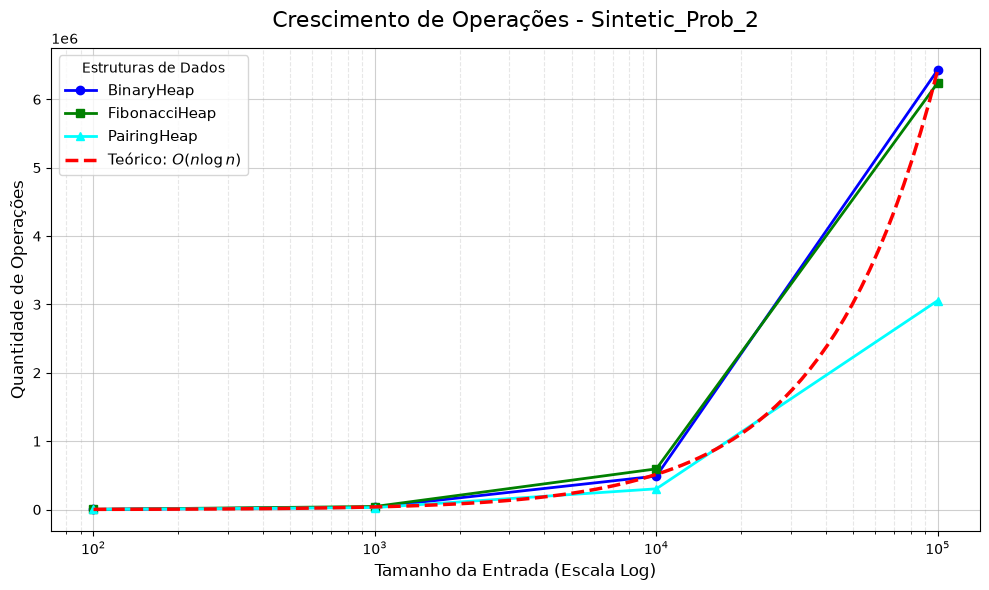

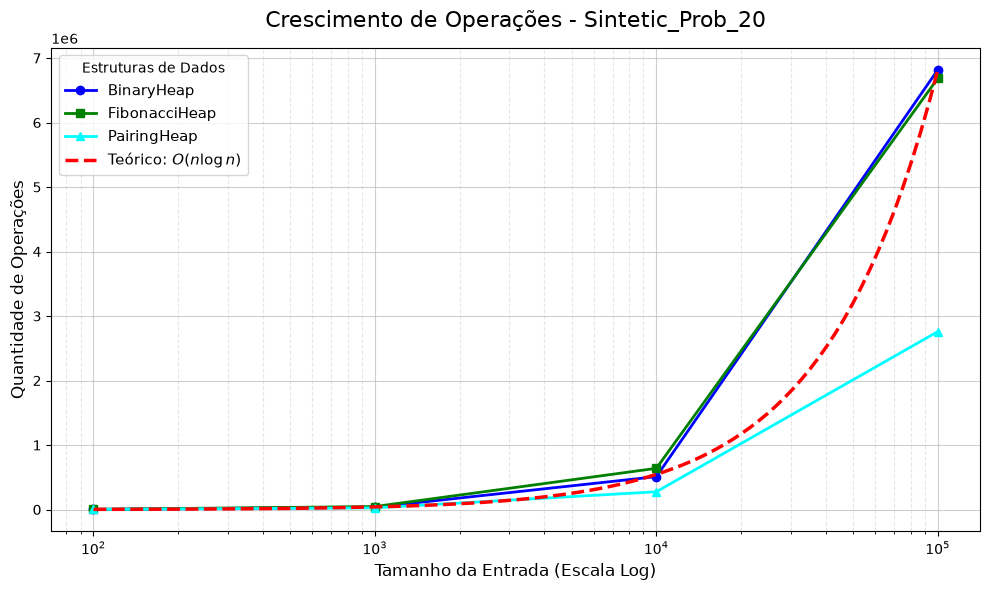

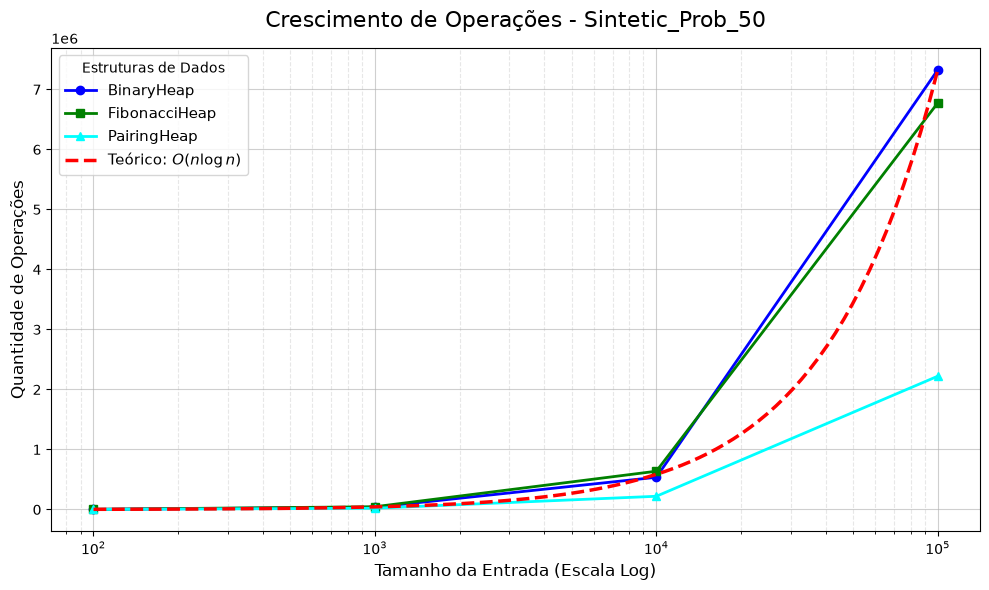

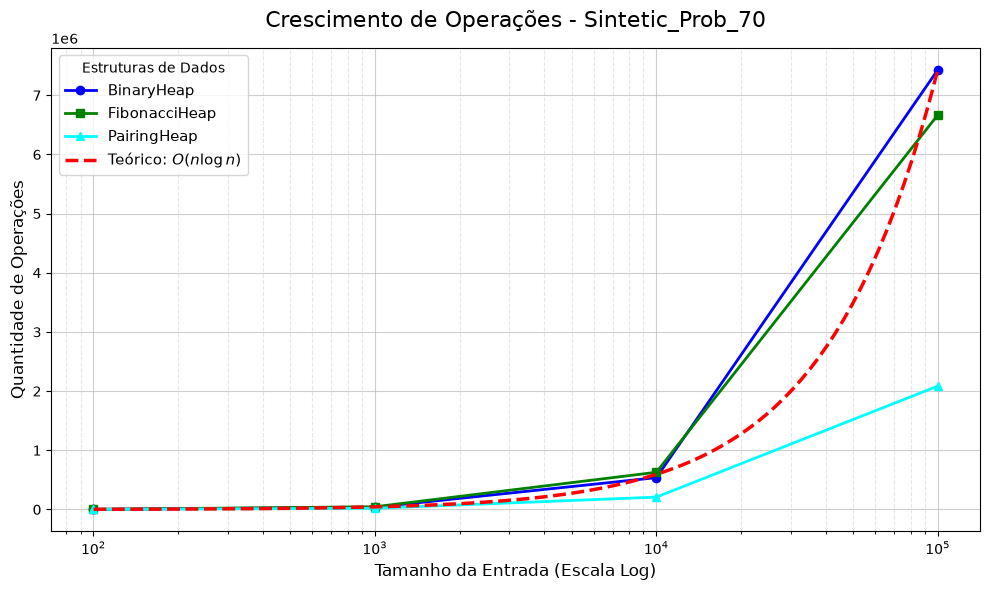

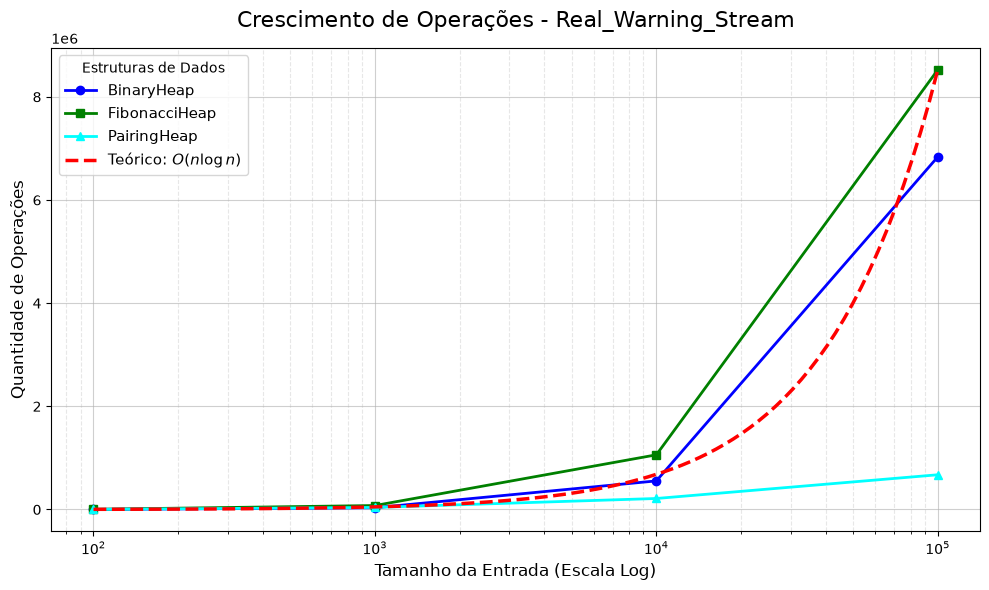

In [24]:
plot_operacoes_por_teste(dados_simulados)

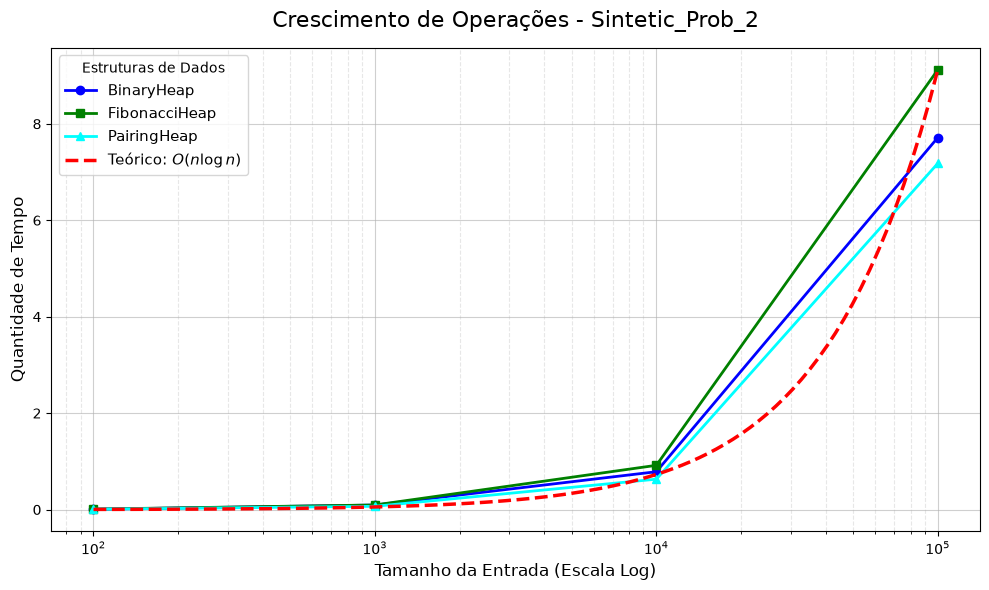

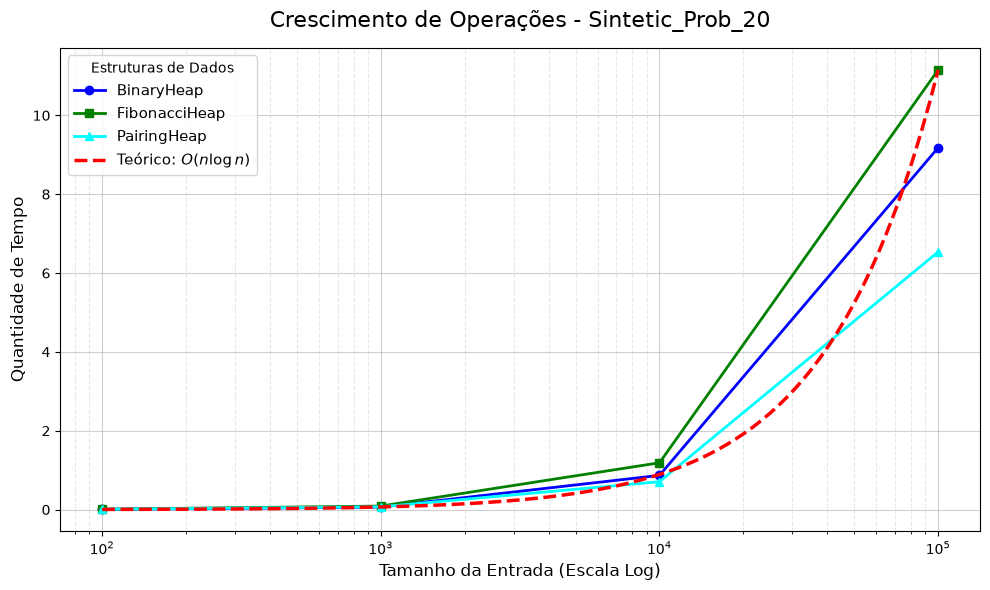

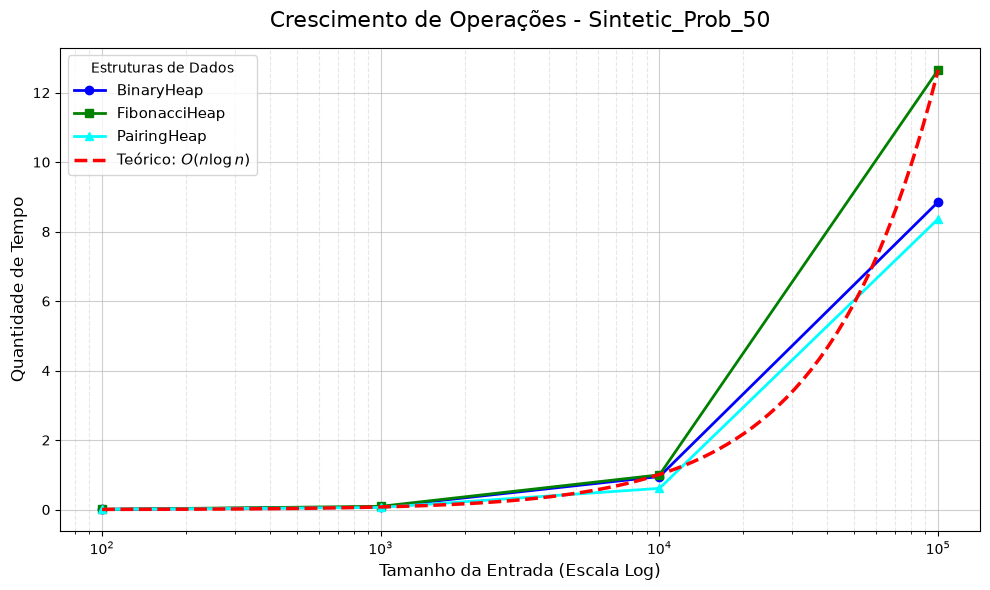

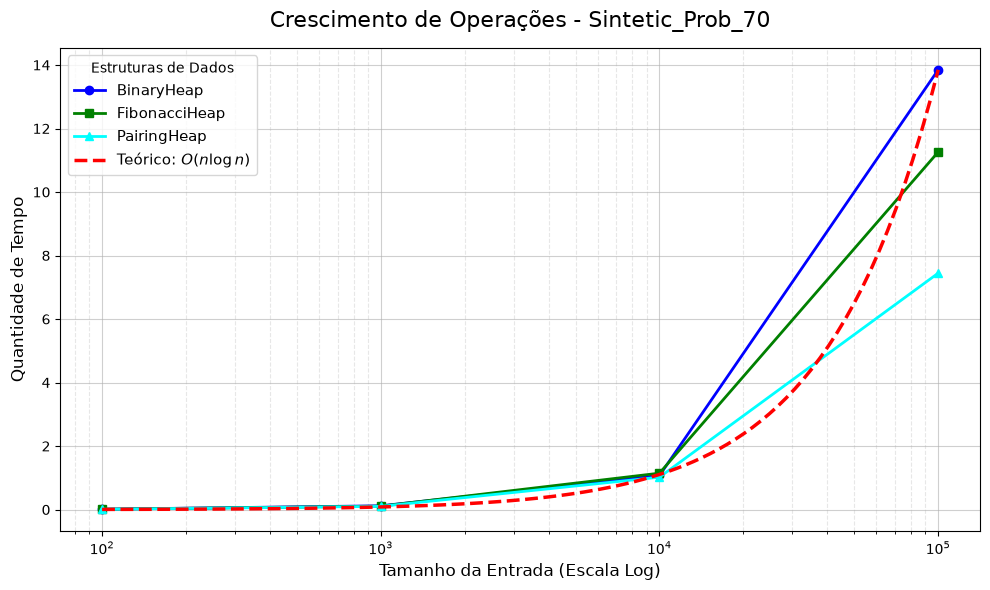

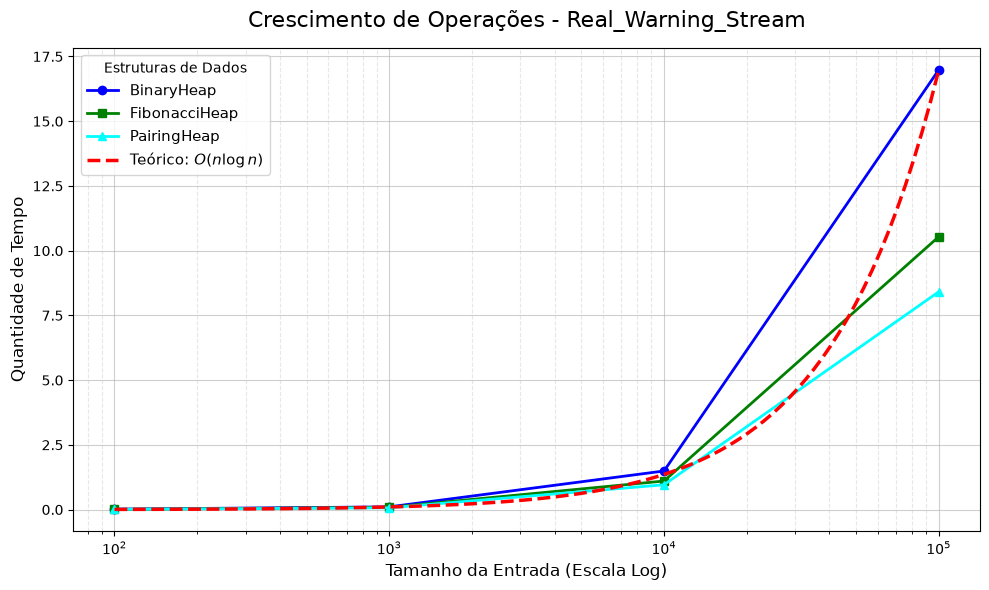

In [25]:
plot_operacoes_por_teste(dados_simulados, 1)